In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from itertools import product

from typing import Dict, Iterable, List, Literal, Optional, Tuple

# Utilities

In [3]:
def make_BA_dataset(N,n,m=2):
    adj = np.empty((N,n,n), dtype=np.float32)
    for j in range(N):
        g = nx.barabasi_albert_graph(n=n,m=m)
        a = np.zeros((n,n), dtype=np.float32)
        for i in g.edges:
            a[i] = 1
            a[i[::-1]] = 1
        adj[j] = a
    return adj

def make_ER_dataset(N,n,p=0.1):
    adj = np.empty((N,n,n), dtype=np.float32)
    for j in range(N):
        g = nx.erdos_renyi_graph(n=n, p=p)
        a = np.zeros((n,n), dtype=np.float32)
        for i in g.edges:
            a[i] = 1
            a[i[::-1]] = 1
        adj[j] = a
    return adj

In [4]:
def set_seed(seed: int) -> np.random.Generator:
    return np.random.default_rng(seed)

In [5]:
def graph_to_adj(g: nx.Graph) -> np.ndarray:
    """Undirected simple graph -> adjacency matrix (float64), zero diagonal."""
    a = nx.to_numpy_array(g, dtype=float)
    np.fill_diagonal(a, 0.0)
    # ensure symmetry
    if not np.allclose(a, a.T):
        a = np.maximum(a, a.T)
    return a

In [6]:
def sample_ER(n: int, p: float, seed: int = None) -> np.ndarray:
    g = nx.erdos_renyi_graph(n=n, p=p, seed=seed, directed=False)
    return graph_to_adj(g)

In [7]:
def sample_BA(n: int, m: int, seed: int = None) -> np.ndarray:
    g = nx.barabasi_albert_graph(n=n, m=m, seed=seed)
    return graph_to_adj(g)

In [8]:
def normalize_adj(A: np.ndarray, how: Literal["none", "row", "sym"]) -> np.ndarray:
    """Return A, D^{-1}A, or D^{-1/2}AD^{-1/2}."""
    if how == "none":
        return A
    d = A.sum(axis=1)
    if how == "row":
        with np.errstate(divide="ignore"):
            invd = np.divide(1.0, d, out=np.zeros_like(d), where=d > 0)
        return (invd[:, None]) * A
    if how == "sym":
        with np.errstate(divide="ignore"):
            invsqrt = np.divide(1.0, np.sqrt(d), out=np.zeros_like(d), where=d > 0)
        return (invsqrt[:, None]) * A * (invsqrt[None, :])
    raise ValueError(f"unknown normalization: {how}")

def adj_power(A: np.ndarray, k: int) -> np.ndarray:
    """Dense power; returns A^k (float64)."""
    if k == 1:
        return A.astype(float, copy=True)
    out = A.astype(float, copy=True)
    for _ in range(1, k):
        out = out @ A
    return out

In [9]:
def ensemble_moments(
    generator_fn,
    gen_args: Tuple,
    orders: Iterable[int],
    N: int,
    normalization: Literal["none", "row", "sym"] = "none",
    rng: np.random.Generator = None,
) -> Dict[int, np.ndarray]:
    """Monte Carlo estimate of E[(A_norm)^k] over an ensemble."""
    n = gen_args[0]  # first arg is n for both ER and BA
    sums: Dict[int, np.ndarray] = {k: np.zeros((n, n), float) for k in orders}
    rng = rng or set_seed(0)
    for _ in range(N):
        seed = int(rng.integers(0, 1_000_000_000))
        A = generator_fn(*gen_args, seed=seed)
        A = normalize_adj(A, normalization)
        for k in orders:
            sums[k] += adj_power(A, k)
    return {k: sums[k] / N for k in orders}

In [10]:
def er_theory(n: int, p: float, normalization: Literal["none", "row", "sym"]) -> Dict[int, np.ndarray]:
    """
    Closed-form E[A] and E[A^2] for ER(n,p).
    - For 'none': classic formulas.
    - For 'row' (D^{-1}A) and 'sym' (D^{-1/2}AD^{-1/2}), exact closed forms depend on random degrees.
      We do not provide closed forms there (return empty dict for those modes).
    """
    if normalization != "none":
        return {}  # degrees are random; closed forms are nontrivial
    I = np.eye(n)
    J = np.ones((n, n))
    EA = p * (J - I)
    EA2 = np.full((n, n), (n - 2) * p * p, float)
    np.fill_diagonal(EA2, (n - 1) * p)
    return {1: EA, 2: EA2}

In [11]:
def _neighbor_probs(A: np.ndarray, v: int, scheme: str, deg: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (neighbors, probs) for node v under a given proposal scheme.
    scheme in {"uniform", "deg"}.
    """
    nb = np.flatnonzero(A[v] > 0)
    if nb.size == 0:
        return nb, np.array([])
    if scheme == "uniform":
        probs = np.full(nb.size, 1.0 / nb.size, dtype=float)
    elif scheme == "deg":
        w = deg[nb].astype(float)
        s = w.sum()
        if s == 0:
            probs = np.full(nb.size, 1.0 / nb.size, dtype=float)
        else:
            probs = w / s
    else:
        raise ValueError(f"unknown proposal scheme: {scheme}")
    return nb, probs

In [12]:
def rw_importance_estimate_Ak(
    A: np.ndarray,
    L: int,
    walks_per_node: int,
    rng: np.random.Generator,
    proposal: Literal["uniform", "deg"] = "uniform",
    rao_blackwell_last_step: bool = True,
) -> np.ndarray:
    """
    Unbiased estimator of A^L with two variance-reduction options:
      - proposal: choose transitions uniformly or proportional to neighbor degree
      - rao_blackwell_last_step: collapse the last step by adding A[row_v, :]
        instead of a delta at the final node
    """
    n = A.shape[0]
    deg = A.sum(axis=1).astype(int)
    est = np.zeros((n, n), float)

    for i in range(n):
        if deg[i] == 0:
            continue

        for _ in range(walks_per_node):
            v = i
            weight_inv = 1.0  # accumulate 1 / q along the path

            # Walk the first L-1 steps; we will treat the last step specially if requested
            steps_to_sample = L - 1 if rao_blackwell_last_step and L >= 1 else L
            ok = True
            for _step in range(steps_to_sample):
                nb, probs = _neighbor_probs(A, v, scheme=proposal, deg=deg)
                if nb.size == 0:
                    ok = False
                    break
                idx = rng.choice(len(nb), p=probs)
                u = nb[idx]
                weight_inv *= 1.0 / probs[idx]
                v = u
            if not ok:
                continue

            if rao_blackwell_last_step and L >= 1:
                # Add the entire next-step distribution analytically: row v of A
                # This contributes to all j with weight 1/q(path) times A[v, j]
                est[i, :] += weight_inv * A[v, :]
            else:
                # Sample the actual last step (or we were doing all L steps)
                if L == 0:
                    est[i, i] += weight_inv
                else:
                    nb, probs = _neighbor_probs(A, v, scheme=proposal, deg=deg)
                    if nb.size == 0:
                        continue
                    idx = rng.choice(len(nb), p=probs)
                    u = nb[idx]
                    weight_inv *= 1.0 / probs[idx]
                    est[i, u] += weight_inv

        # Average over the number of walks for source i
        est[i, :] /= max(1, walks_per_node)

    return est

In [13]:
def summarize_matrix(M: np.ndarray) -> Dict[str, float]:
    """Cheap per-entry summary (off-diag & diag means/stds)."""
    n = M.shape[0]
    off = M[~np.eye(n, dtype=bool)]
    diag = np.diag(M)
    return {
        "mean_offdiag": float(np.mean(off)),
        "std_offdiag": float(np.std(off)),
        "mean_diag": float(np.mean(diag)),
        "std_diag": float(np.std(diag)),
        "min": float(np.min(M)),
        "max": float(np.max(M)),
    }

In [14]:
def compare_estimate_vs_exact(A: np.ndarray, L: int, walks_per_node: int, rng: np.random.Generator) -> Dict[str, float]:
    exact = adj_power(A, L)
    est = rw_importance_estimate_Ak(A, L=L, walks_per_node=walks_per_node, rng=rng)
    diff = est - exact
    rmse = float(np.sqrt(np.mean(diff**2)))
    denom = float(np.mean(np.abs(exact)))
    rel_rmse = rmse / denom if denom > 0 else np.nan
    return {"L": L, "rmse": rmse, "rel_rmse": rel_rmse}

In [15]:
def evaluate_generator(
    generator_fn,
    gen_args: Tuple,
    orders: Iterable[int],
    N_graphs: int,
    walks_per_node: int,
    normalization: Literal["none", "row", "sym"] = "none",
    seed: int = 0,
):
    """
    For each fresh graph from the generator, compute exact A^L (or (A_norm)^L for normalized mode),
    estimate with RW-IS (matching normalization 'none' only; see note below), and report errors.
    """
    rng = set_seed(seed)
    results = []
    for _ in range(N_graphs):
        A = generator_fn(*gen_args, seed=int(rng.integers(0, 1_000_000_000)))
        A_norm = normalize_adj(A, normalization)

        # NOTE: The RW estimator implemented here matches the *unnormalized* A walk.
        # If you want to estimate powers of A_hat = D^{-1}A instead, you can:
        #   - either compute them exactly from A_hat (recommended),
        #   - or sample transitions according to A_hat's row-stochastic matrix (same estimator).
        for L in orders:
            # exact on normalized matrix:
            exact = adj_power(A_norm, L)

            if normalization == "none":
                est = rw_importance_estimate_Ak(A, L=L, walks_per_node=walks_per_node, rng=rng)
            elif normalization == "row":
                est = rw_importance_estimate_Ak(normalize_adj(A, "row"), L=L, walks_per_node=walks_per_node, rng=rng)
            elif normalization == "sym":
                # symmetric normalization is not a Markov transition; prefer exact computation
                est = exact.copy()
            else:
                raise ValueError("bad normalization")

            diff = est - exact
            rmse = float(np.sqrt(np.mean(diff**2)))
            denom = float(np.mean(np.abs(exact)))
            rel_rmse = rmse / denom if denom > 0 else np.nan
            results.append({"L": L, "rmse": rmse, "rel_rmse": rel_rmse})
    if pd is not None:
        return pd.DataFrame(results)
    return results

In [16]:
def compute_exact_moments(A: np.ndarray, orders=(1,2,3,4), normalization="none"):
    """Return dict: p -> A^p (matrix) for chosen normalization."""
    Ause = normalize_adj(A, normalization)
    return {p: adj_power(Ause, p) for p in orders}

def estimate_moments_rw(
    A: np.ndarray, orders=(1,2,3,4), walks_per_node=600, seed: int = 0,
    proposal="uniform", rao_blackwell_last_step=True, normalization="none"
):
    """
    Estimate A^p via random-walk importance sampling.
    If normalization == "row", we estimate powers of D^{-1}A by walking on that kernel.
    If normalization == "sym", use exact powers instead (not a Markov kernel).
    """
    rng = np.random.default_rng(seed)
    out = {}
    if normalization == "sym":
        # Not a random-walk kernel; fall back to exact
        Ause = normalize_adj(A, normalization)
        return {p: adj_power(Ause, p) for p in orders}

    if normalization == "row":
        Ause = normalize_adj(A, "row")
    else:
        Ause = A

    for p in orders:
        out[p] = rw_importance_estimate_Ak(
            Ause, L=p, walks_per_node=walks_per_node, rng=rng, proposal=proposal,
            rao_blackwell_last_step=rao_blackwell_last_step,
        )
    return out

def error_metrics(exact: np.ndarray, est: np.ndarray) -> Dict[str, float]:
    diff = est - exact
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae  = float(np.mean(np.abs(diff)))
    denom = float(np.mean(np.abs(exact)))
    rel_rmse = rmse / denom if denom > 0 else np.nan
    rel_mae  = mae  / denom if denom > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "rel_rmse": rel_rmse, "rel_mae": rel_mae}

In [18]:
class ExpConfig:
    seed: int = 0
    # graph moments A^p to compute
    orders: tuple = (1, 2, 3, 4)
    # RW budget per node per L (tune up for lower variance)
    walks_per_node: int = 200
    # how many graphs per (model, hyperparams)
    graphs_per_setting: int = 10
    # moments of A, D^-1 A, or D^-1/2 A D^-1/2
    normalization: Literal["none","row","sym"] = "none"
    # whether to perform random walks over neighbors uniformly or biased by neighbor degree
    proposal: Literal["uniform","deg"] = "uniform"
    # whether to collapse last step with Rao-Blackwell estimator
    rao_blackwell_last_step: bool = True

In [19]:
def sample_graph(setting: dict, seed: int):
    if setting["model"] == "ER":
        return sample_ER(setting["n"], setting["p"], seed=seed)
    else:
        return sample_BA(setting["n"], setting["m"], seed=seed)

def run_setting(setting: dict, cfg: ExpConfig, rng: np.random.Generator):
    """
    For one (model, hyperparams) setting:
      - sample cfg.graphs_per_setting graphs
      - compute exact and RW-estimated A^p
      - return a DataFrame of errors for each graph and each p
    """
    rows = []
    for g_idx in range(cfg.graphs_per_setting):
        A = sample_graph(setting, int(rng.integers(1_000_000_000)))

        exact = compute_exact_moments(A, orders=cfg.orders, normalization=cfg.normalization)
        est = estimate_moments_rw(
            A,
            orders=cfg.orders,
            walks_per_node=cfg.walks_per_node,
            seed=int(rng.integers(1_000_000_000)),
            proposal=cfg.proposal,
            rao_blackwell_last_step=cfg.rao_blackwell_last_step,
            normalization=cfg.normalization,
        )

        for p in cfg.orders:
            m = error_metrics(exact[p], est[p])
            row = {
                "model": setting["model"],
                "n": setting["n"],
                "p_param": setting.get("p", np.nan),
                "m_param": setting.get("m", np.nan),
                "graph_idx": g_idx,
                "moment_p": p,
                "normalization": cfg.normalization,
                **m
            }
            rows.append(row)
    return pd.DataFrame(rows)

def run_all(settings: list, cfg: ExpConfig, seed: int = 0):
    rng = set_seed(seed)
    dfs = []
    for s in settings:
        print(f"Running: {s}")
        df = run_setting(s, cfg, rng)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

# Experiment

## Config

In [20]:
CFG = ExpConfig()

In [21]:
# hyperparameter grids
ER_ns = [20, 40, 80]
ER_ps = [0.05, 0.1, 0.2]
BA_ns = [20, 40, 80]
BA_ms = [2, 3, 5]

# Build lists of settings to run
ER_settings = [{"model": "ER", "n": n, "p": p} for n, p in product(ER_ns, ER_ps)]
BA_settings = [{"model": "BA", "n": n, "m": m} for n, m in product(BA_ns, BA_ms)]

ALL_SETTINGS = ER_settings + BA_settings

rng_master = set_seed(CFG.seed)

## Run

In [22]:
# results = run_all(
#     ALL_SETTINGS, CFG, seed=CFG.seed
# )
# print(results.shape)
# results[:3]

# Analysis

## Plotting utilities

In [23]:
def plot_rel_rmse_by_p(results: pd.DataFrame, model: str):
    sub = results[results["model"] == model].copy()
    if model == "ER":
        key = "p_param"
        label = "p (edge prob)"
    else:
        key = "m_param"
        label = "m (BA attachment)"
    # aggregate by hyperparameter and p
    agg = sub.groupby([key, "moment_p"]).agg(mean_rel_rmse=("rel_rmse", "mean"),
                                             std_rel_rmse=("rel_rmse", "std")).reset_index()

    # plot one line per hyperparameter setting
    plt.figure()
    for k, d in agg.groupby(key):
        xs = d["moment_p"].values
        ys = d["mean_rel_rmse"].values
        plt.plot(xs, ys, marker="o", label=f"{label}={k}")
    plt.xlabel("moment order p")
    plt.ylabel("mean relative RMSE")
    plt.title(f"{model}: estimation error vs. moment order")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [24]:
def bar_rel_rmse(results: pd.DataFrame, model: str, p: int):
    sub = results[(results["model"] == model) & (results["moment_p"] == p)].copy()
    if model == "ER":
        key = "p_param"; title_key = "p"
    else:
        key = "m_param"; title_key = "m"
    agg = sub.groupby(key).agg(mean_rel_rmse=("rel_rmse","mean"), std_rel_rmse=("rel_rmse","std")).reset_index()

    plt.figure()
    plt.bar(agg[key].astype(str), agg["mean_rel_rmse"].values)
    plt.xlabel(title_key)
    plt.ylabel("mean relative RMSE")
    plt.title(f"{model} – p={p}: mean relative RMSE by hyperparameter")
    plt.tight_layout()
    plt.show()

## Plot

# Extension to Temporal Graph Moments

In [39]:
@dataclass
class TempConfig:
    seed: int = 0
    # which moments (lengths) to compute per sequence
    Ls: tuple = (1, 2, 3, 4)
    # temporal sequence length (number of time windows)
    # T: int = 8
    # random-walk budget (per source, per (t0,L))
    walks_per_node: int = 200
    # number of independent sequences to generate for each hyperparameter setting
    sequences_per_setting: int = 10
    # normalization for moments: "none", "row", or "sym"
    normalization: Literal["none","row","sym"] = "none"
    # random-walk proposal: "uniform" or "deg" (degree-biased)
    proposal: Literal["uniform","deg"] = "uniform"
    # use Rao–Blackwell on the last step (big variance reduction)
    rao_blackwell_last_step: bool = True

TEMP_CFG = TempConfig()

In [31]:
def make_temporal_ER_sequence(n: int, p: float, T: int, seed: Optional[int] = None):
    rng = np.random.default_rng(seed)
    return [sample_ER(n, p, seed=int(rng.integers(1_000_000_000))) for _ in range(T)]

def make_temporal_BA_sequence(n: int, m: int, T: int, seed: Optional[int] = None):
    rng = np.random.default_rng(seed)
    return [sample_BA(n, m, seed=int(rng.integers(1_000_000_000))) for _ in range(T)]

In [32]:
def temporal_causal_products(A_list, L: int, normalization="none"):
    """
    Returns list [ M_L(t0) for t0=0..T-L ]
    """
    Aseq = [normalize_adj(A, normalization) for A in A_list]
    T = len(Aseq)
    outs = []
    for t0 in range(max(0, T - L + 1)):
        M = Aseq[t0].astype(float, copy=True)
        for s in range(1, L):
            M = M @ Aseq[t0 + s]
        outs.append(M)
    return outs  # length = T-L+1 (possibly 0 if L>T)

def temporal_causal_products_range(A_list, Ls, normalization="none", t0s=None):
    """
    Returns dict: { L: { t0: M_L(t0) } }
    If t0s is None: use all valid t0 for each L.
    """
    out = {}
    T = len(A_list)
    for L in Ls:
        Ms = temporal_causal_products(A_list, L, normalization)
        if len(Ms) == 0:
            out[L] = {}
            continue
        if t0s is None:
            out[L] = {t0: Ms[t0] for t0 in range(T - L + 1)}
        else:
            valid = {t0: Ms[t0] for t0 in t0s if 0 <= t0 <= T - L}
            out[L] = valid
    return out

def temporal_average_moment(A_list, L, normalization="none", weights=None):
    Ms = temporal_causal_products(A_list, L, normalization)
    if len(Ms) == 0:
        return None
    if weights is None:
        return sum(Ms) / len(Ms)
    w = np.asarray(weights, dtype=float)
    w = w[:len(Ms)]
    w = w / w.sum()
    return sum(w[k] * Ms[k] for k in range(len(Ms)))


In [ ]:
def _neighbor_probs_temporal(A_t, v, scheme, deg_t):
    nb = np.flatnonzero(A_t[v] > 0)
    if nb.size == 0:
        return nb, np.array([])
    if scheme == "uniform":
        probs = np.full(nb.size, 1.0 / nb.size)
    elif scheme == "deg":
        w = deg_t[nb].astype(float)
        s = w.sum()
        probs = (w / s) if s > 0 else np.full(nb.size, 1.0 / nb.size)
    else:
        raise ValueError(scheme)
    return nb, probs

def rw_estimate_temporal_M_single(
    A_list,
    L: int,
    t0: int,
    walks_per_node: int,
    rng: np.random.Generator,
    normalization: Literal["none","row","sym"] = "none",
    proposal: Literal["uniform","deg"] = "uniform",
    rao_blackwell_last_step: bool = True,
):
    """
    Estimate M_L(t0) (n x n) using time-respecting random walks starting at slice t0.
    """
    T = len(A_list)
    assert 0 <= t0 <= T - L, "t0 out of range for given L and T"

    # For "sym" normalization, easiest is to compute exact product (not a Markov kernel).
    if normalization == "sym":
        return temporal_causal_products(A_list, L, normalization="sym")[t0]

    # Decide which matrices to walk on
    if normalization == "row":
        Aseq = [normalize_adj(A, "row") for A in A_list]
    else:
        Aseq = A_list

    n = Aseq[0].shape[0]
    Mhat = np.zeros((n, n), float)
    degs = [A.sum(axis=1).astype(int) for A in Aseq]

    for i in range(n):
        # if unnormalized and the start is isolated at t0, skip
        if normalization != "row" and degs[t0][i] == 0:
            continue

        for _ in range(walks_per_node):
            v = i
            weight_inv = 1.0
            ok = True

            steps_to_sample = L - 1 if rao_blackwell_last_step and L >= 1 else L
            for s in range(steps_to_sample):
                A_t = Aseq[t0 + s]
                deg_t = degs[t0 + s]
                nb, probs = _neighbor_probs_temporal(A_t, v, proposal, deg_t)
                if nb.size == 0:
                    ok = False
                    break
                idx = rng.choice(len(nb), p=probs)
                u = nb[idx]
                weight_inv *= 1.0 / probs[idx]
                v = u

            if not ok:
                continue

            if rao_blackwell_last_step and L >= 1:
                A_last = Aseq[t0 + L - 1]
                Mhat[i, :] += weight_inv * A_last[v, :]
            else:
                if L == 0:
                    Mhat[i, i] += weight_inv
                else:
                    A_last = Aseq[t0 + L - 1]
                    deg_last = degs[t0 + L - 1]
                    nb, probs = _neighbor_probs_temporal(A_last, v, proposal, deg_last)
                    if nb.size == 0:
                        continue
                    idx = rng.choice(len(nb), p=probs)
                    u = nb[idx]
                    weight_inv *= 1.0 / probs[idx]
                    Mhat[i, u] += weight_inv

        Mhat[i, :] /= max(1, walks_per_node)

    return Mhat

def rw_estimate_temporal_M_range(
    A_list,
    Ls,
    walks_per_node: int,
    seed: int = 0,
    normalization: Literal["none","row","sym"] = "none",
    proposal: Literal["uniform","deg"] = "uniform",
    rao_blackwell_last_step: bool = True,
    t0s=None,
):
    """
    Returns dict: { L: { t0: Mhat_L(t0) } } over requested Ls and t0s (default: all valid t0).
    """
    rng = np.random.default_rng(seed)
    T = len(A_list)
    out = {}
    for L in Ls:
        valid_t0s = range(T - L + 1) if t0s is None else [t for t in t0s if 0 <= t <= T - L]
        d = {}
        for t0 in valid_t0s:
            d[t0] = rw_estimate_temporal_M_single(
                A_list, L, t0, walks_per_node, rng,
                normalization=normalization,
                proposal=proposal,
                rao_blackwell_last_step=rao_blackwell_last_step
            )
        out[L] = d
    return out

In [34]:
def temporal_eval_errors(exact_dict, est_dict):
    """
    exact_dict and est_dict have shape { L: { t0: matrix } }.
    Returns a flat DataFrame with RMSE/RelRMSE for each (L,t0).
    """
    rows = []
    for L, exact_t0s in exact_dict.items():
        for t0, M in exact_t0s.items():
            E = est_dict.get(L, {}).get(t0, None)
            if E is None:
                continue
            diff = E - M
            rmse = float(np.sqrt(np.mean(diff**2)))
            denom = float(np.mean(np.abs(M)))
            rel = rmse / denom if denom > 0 else np.nan
            rows.append({"L": L, "t0": t0, "rmse": rmse, "rel_rmse": rel})
    return pd.DataFrame(rows) if pd is not None else rows

In [35]:
def build_temporal_settings_ER(ns, ps, Ts):
    return [{"model": "ER", "n": n, "p": p, "T": T} for n in ns for p in ps for T in Ts]

def build_temporal_settings_BA(ns, ms, Ts):
    return [{"model": "BA", "n": n, "m": m, "T": T} for n in ns for m in ms for T in Ts]

def sample_temporal_sequence(setting, seed):
    if setting["model"] == "ER":
        return make_temporal_ER_sequence(setting["n"], setting["p"], setting["T"], seed=seed)
    else:
        return make_temporal_BA_sequence(setting["n"], setting["m"], setting["T"], seed=seed)

def run_temporal_setting(setting, cfg: TempConfig, seed: int):
    rng = np.random.default_rng(seed)
    all_rows = []
    for sidx in range(cfg.sequences_per_setting):
        A_list = sample_temporal_sequence(setting, seed=int(rng.integers(1_000_000_000)))

        # exact temporal moments for all valid t0
        exact = temporal_causal_products_range(A_list, cfg.Ls, normalization=cfg.normalization)

        # estimates (same L and t0 coverage)
        est = rw_estimate_temporal_M_range(
            A_list, cfg.Ls, walks_per_node=cfg.walks_per_node,
            seed=int(rng.integers(1_000_000_000)),
            normalization=cfg.normalization,
            proposal=cfg.proposal,
            rao_blackwell_last_step=cfg.rao_blackwell_last_step,
            t0s=None
        )

        df = temporal_eval_errors(exact, est)
        if pd is not None:
            df["model"] = setting["model"]
            df["n"] = setting["n"]
            df["p_param"] = setting.get("p", np.nan)
            df["m_param"] = setting.get("m", np.nan)
            df["T"] = setting["T"]
            df["seq_idx"] = sidx
        all_rows.append(df)
    return pd.concat(all_rows, ignore_index=True) if pd is not None else all_rows

def run_temporal_all(settings, cfg: TempConfig, seed: int = 0):
    out = []
    for s in settings:
        print("Temporal run:", s)
        out.append(run_temporal_setting(s, cfg, seed=seed))
        seed += 1
    return pd.concat(out, ignore_index=True)

In [36]:
def plot_temporal_relrmse_vs_L(df: pd.DataFrame, model: str):
    sub = df[df["model"] == model].copy()
    if model == "ER":
        key = "p_param"; lab = "p (edge prob)"
    else:
        key = "m_param"; lab = "m (attachment)"
    agg = sub.groupby([key, "T", "L"]).agg(mean_rel=("rel_rmse","mean"), std_rel=("rel_rmse","std")).reset_index()

    # one figure per T
    Ts = sorted(agg["T"].unique())
    for T in Ts:
        dT = agg[agg["T"] == T]
        plt.figure()
        for k, d in dT.groupby(key):
            xs = d["L"].values
            ys = d["mean_rel"].values
            plt.plot(xs, ys, marker="o", label=f"{lab}={k}")
        plt.xlabel("L (temporal length)")
        plt.ylabel("mean relative RMSE")
        plt.title(f"{model} temporal: RelRMSE vs L (T={T})")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [40]:
# Grids (edit freely)
ER_ns = [20, 40, 80]
ER_ps = [0.05, 0.1, 0.2]
BA_ns = [20, 40, 80]
BA_ms = [2, 3, 5]
Ts = [4, 8]

TEMP_CFG = TempConfig(
    seed=0,
    Ls=(1, 2, 3, 4),
    # T=4,  # Not used, Ls determines walk length
    walks_per_node=200,
    sequences_per_setting=4,
    normalization="none",
    proposal="uniform",
    rao_blackwell_last_step=True,
)

temp_settings = (
    build_temporal_settings_ER(ER_ns, ER_ps, Ts) +
    build_temporal_settings_BA(BA_ns, BA_ms, Ts)
)

temp_results = run_temporal_all(temp_settings, TEMP_CFG, seed=TEMP_CFG.seed)
temp_results.head()

Temporal run: {'model': 'ER', 'n': 20, 'p': 0.05, 'T': 4}
Temporal run: {'model': 'ER', 'n': 20, 'p': 0.05, 'T': 8}
Temporal run: {'model': 'ER', 'n': 20, 'p': 0.1, 'T': 4}
Temporal run: {'model': 'ER', 'n': 20, 'p': 0.1, 'T': 8}
Temporal run: {'model': 'ER', 'n': 20, 'p': 0.2, 'T': 4}
Temporal run: {'model': 'ER', 'n': 20, 'p': 0.2, 'T': 8}
Temporal run: {'model': 'ER', 'n': 40, 'p': 0.05, 'T': 4}
Temporal run: {'model': 'ER', 'n': 40, 'p': 0.05, 'T': 8}
Temporal run: {'model': 'ER', 'n': 40, 'p': 0.1, 'T': 4}
Temporal run: {'model': 'ER', 'n': 40, 'p': 0.1, 'T': 8}
Temporal run: {'model': 'ER', 'n': 40, 'p': 0.2, 'T': 4}
Temporal run: {'model': 'ER', 'n': 40, 'p': 0.2, 'T': 8}
Temporal run: {'model': 'ER', 'n': 80, 'p': 0.05, 'T': 4}
Temporal run: {'model': 'ER', 'n': 80, 'p': 0.05, 'T': 8}
Temporal run: {'model': 'ER', 'n': 80, 'p': 0.1, 'T': 4}
Temporal run: {'model': 'ER', 'n': 80, 'p': 0.1, 'T': 8}
Temporal run: {'model': 'ER', 'n': 80, 'p': 0.2, 'T': 4}
Temporal run: {'model': '

,L,t0,rmse,rel_rmse,model,n,p_param,m_param,T,seq_idx
0,1,0,0.000000,0.000000,ER,20,0.05,NaN,4,0
1,1,1,0.000000,0.000000,ER,20,0.05,NaN,4,0
2,1,2,0.000000,0.000000,ER,20,0.05,NaN,4,0
3,1,3,0.000000,0.000000,ER,20,0.05,NaN,4,0
4,2,0,0.013153,0.404706,ER,20,0.05,NaN,4,0


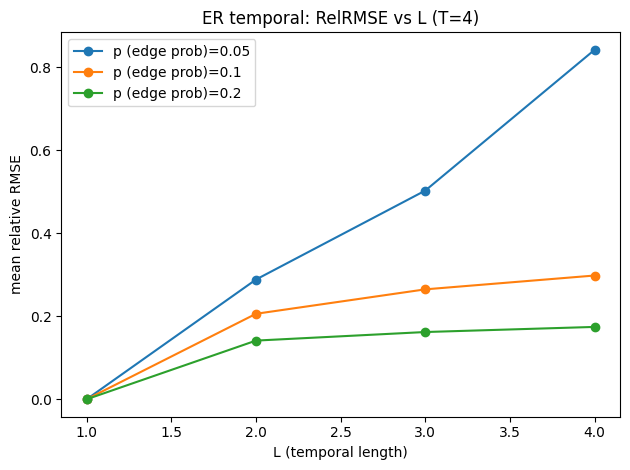

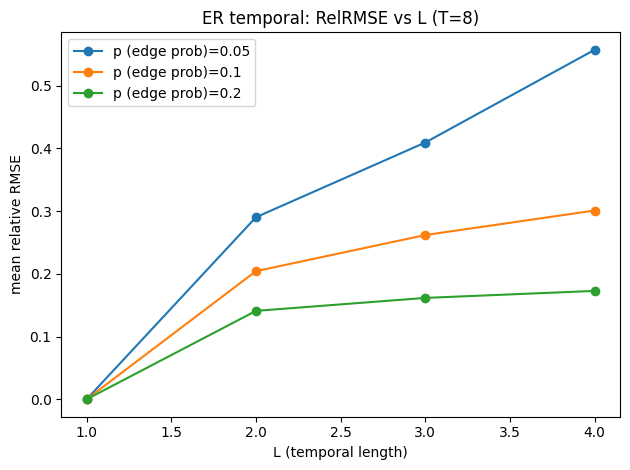

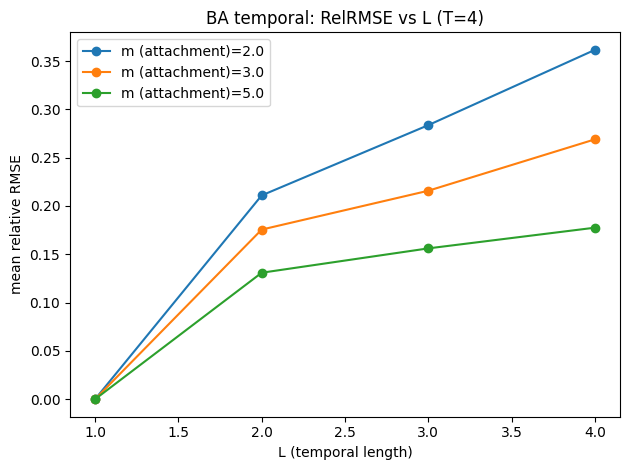

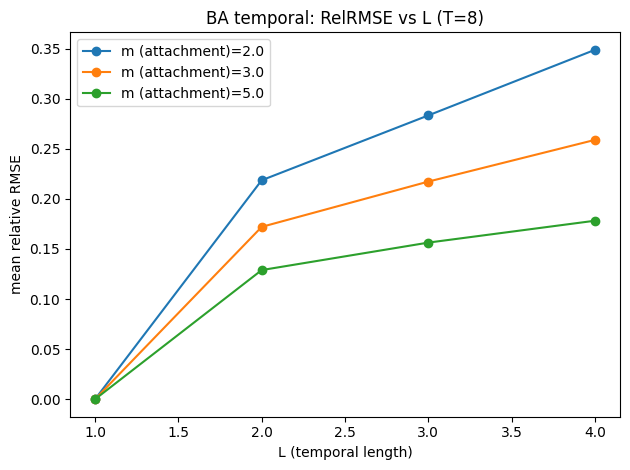

In [42]:
plot_temporal_relrmse_vs_L(temp_results, model="ER")
plot_temporal_relrmse_vs_L(temp_results, model="BA")